In [1]:
# Penn-Fudan Pedestrian Detection Dataset 사용
# 환경 설정 및 필수 라이브러리
import torch
import torchvision
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision import transforms as T
import torch.utils.data as data
from torch.utils.data import DataLoader

import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image
import os
import time
from pathlib import Path
from tqdm import tqdm
import zipfile
import urllib.request
import shutil

print(f'PyTorch: {torch.__version__}')
print(f'TorchVision: {torchvision.__version__}')
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')

if device == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB')

PyTorch: 2.11.0+cu128
TorchVision: 0.26.0+cu128
Device: cuda
GPU: NVIDIA L4
GPU Memory: 23.66 GB


Penn-Fudan Dataset 다운로드 중...
다운로드 완료: PennFudanPed.zip
압축 해제 완료: PennFudanPed

=== 데이터셋 구조 ===
이미지: 170개
마스크: 170개


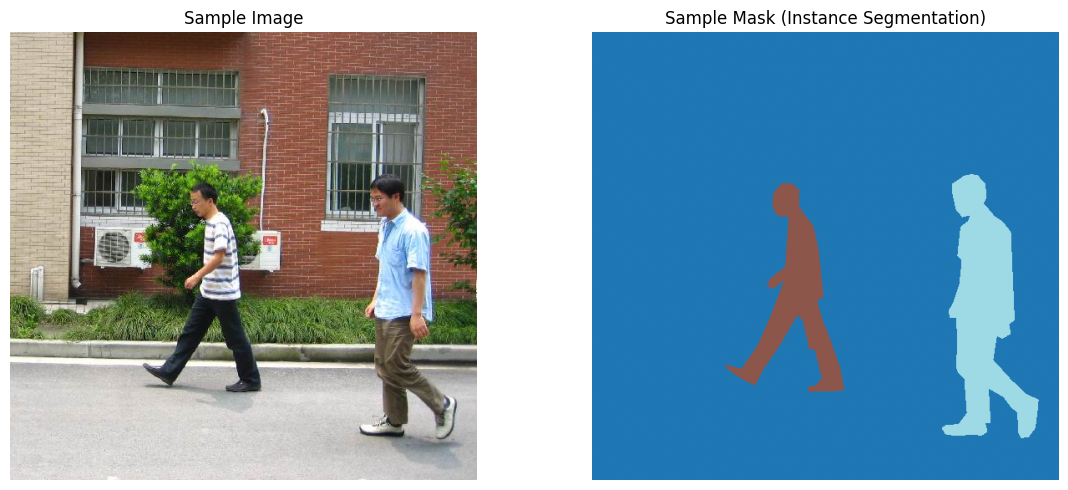

In [2]:
# 데이터셋 다운로드 및 준비
def download_pennfudan_dataset():
    """Penn-Fudan Pedestrian Detection Dataset 다운로드"""

    data_dir = Path('./PennFudanPed')

    if data_dir.exists():
        print(f"데이터셋이 이미 존재합니다: {data_dir}")
        return data_dir

    print("Penn-Fudan Dataset 다운로드 중...")
    url = "https://www.cis.upenn.edu/~jshi/ped_html/PennFudanPed.zip"
    zip_path = "PennFudanPed.zip"

    # 다운로드
    urllib.request.urlretrieve(url, zip_path)
    print(f"다운로드 완료: {zip_path}")

    # 압축 해제
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall('.')
    print(f"압축 해제 완료: {data_dir}")

    # 압축 파일 삭제
    os.remove(zip_path)

    return data_dir

# 데이터셋 다운로드
data_root = download_pennfudan_dataset()

# 데이터 구조 확인
print("\n=== 데이터셋 구조 ===")
print(f"이미지: {len(list((data_root / 'PNGImages').glob('*.png')))}개")
print(f"마스크: {len(list((data_root / 'PedMasks').glob('*.png')))}개")

# 샘플 이미지 확인
sample_img = Image.open(data_root / 'PNGImages' / 'FudanPed00001.png')
sample_mask = Image.open(data_root / 'PedMasks' / 'FudanPed00001_mask.png')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(sample_img)
axes[0].set_title('Sample Image')
axes[0].axis('off')
axes[1].imshow(sample_mask, cmap='tab20')
axes[1].set_title('Sample Mask (Instance Segmentation)')
axes[1].axis('off')
plt.tight_layout()
plt.show()

In [14]:
# Custom Dataset 클래스 정의
class PennFudanDataset(data.Dataset):

    def __init__(self, root, transforms=None):
        self.root = Path(root)
        self.transforms = transforms

        # 모든 이미지와 마스크 파일 로드 / 파일명 순서대로 정렬
        self.imgs = sorted(list((self.root / 'PNGImages').glob('*.png')))
        self.masks = sorted(list((self.root / 'PedMasks').glob('*.png')))

        print(f"Dataset 초기화: {len(self.imgs)}개 이미지")

    def __len__(self):
        return len(self.imgs)

    def __getitem__(self, idx):
        # 이미지 로드
        img_path = self.imgs[idx]
        mask_path = self.masks[idx]

        img = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path)

        # 마스크를 numpy 배열로 변환
        mask = np.array(mask)

        # 각 instance의 고유 ID 추출
        obj_ids = np.unique(mask)
        # 예) obj_ids = [0,1,2]
        # 배경 제거 (ID 0번)
        obj_ids = obj_ids[1:]
        # obj_ids = [1,2] 실제 사람만 추출하겠다

        # 마스크를 binary mask로 분할
        masks = (mask == obj_ids[:, None, None])  # (N, 1, 1) N 객체수
        # 예) obj_ids = [1,2] >> masks[0] 1번 사람 픽셀만 True
        # mask.shape : 2차원 (h, w)
        # 결과적으로  masks 는 (N, H, W)

        # Bounding box 계산
        num_objs = len(obj_ids)
        boxes = []

        for i in range(num_objs):
            pos = np.where(masks[i])
            # masks i 번 순회하면서 True 인 픽셀(y좌표, x좌표) 반환
            xmin = np.min(pos[1])  # 가장 왼쪽에 위치한 x
            xmax = np.max(pos[1])  # 가장 오른쪽에 위치한 x, pos[1] : x 좌표 값들의 배열
            ymin = np.min(pos[0])  # 가장 위쪽에 위치한 y, pos[0] : y 좌표 값들의 배열
            ymax = np.max(pos[0])  # 가장 아래쪽에 위치한 y

            # 유효한 박스만 추가
            if xmax > xmin and ymax > ymin:
                boxes.append([xmin, ymin, xmax, ymax])

        # Tensor로 변환
        boxes = torch.as_tensor(boxes, dtype=torch.float32)    # [x1, y1, x2, y2] >> (n, 4)
        labels = torch.ones((len(boxes),), dtype=torch.int64)  # 모두 사람(class 1) >> (n,)
        masks = torch.as_tensor(masks, dtype=torch.uint8)      # (N, H, W)
        image_id = torch.tensor([idx])                         # (1,)
        area = (boxes[:, 3] - boxes[:, 1]) * (boxes[:, 2] - boxes[:, 0]) # (N)
        # (y2-y1) * (x2-x1)
        iscrowd = torch.zeros((len(boxes),), dtype=torch.int64)
        # 모두 0 (군중 아니야 >> 개별 인스턴스) (N)

        target = {
            'boxes': boxes,
            'labels': labels,
            'masks': masks,
            'image_id': image_id,
            'area': area,
            'iscrowd': iscrowd
        }

        # Transform 적용
        if self.transforms is not None:
            img = self.transforms(img)

        return img, target

In [15]:
# Transform 정의
def get_transform(train=True):
    """데이터 Transform"""
    transforms = []
    transforms.append(T.ToTensor())
    # PIL Image (hwc) (0-255)  >> Tensor(chw) (0-1)
    if train:
        transforms.append(T.RandomHorizontalFlip(0.5))
        # 50% 확률로 좌우 반전
    return T.Compose(transforms)

In [18]:
torch.randperm(5)

tensor([3, 1, 2, 4, 0])

In [20]:
# 데이터 분할 및 DataLoader
# Train/Val 분할
dataset_full = PennFudanDataset(data_root, get_transform(train=True))
# randperm 데이터를 무작위로 섞기 (index 섞기)
indices = torch.randperm(len(dataset_full)).tolist()
# 전체 데이터 다 가져와서 막 섞어 >> 리스트로 만들어
split_idx = int(len(dataset_full) * 0.8)

train_indices = indices[:split_idx]
val_indices = indices[split_idx:]

# Subset 생성
train_dataset = torch.utils.data.Subset(dataset_full, train_indices)
val_dataset_transforms = PennFudanDataset(data_root, get_transform(train=False))
val_dataset = torch.utils.data.Subset(val_dataset_transforms, val_indices)

print(f"\n=== 데이터 분할 ===")
print(f"Train: {len(train_dataset)}개")
print(f"Val: {len(val_dataset)}개")

# DataLoader
def collate_fn(batch):
    return tuple(zip(*batch))
    # 이미지는 이미지대로, target 은 target 끼리 묶어줘
    # 일반적으로 DataLoader에 넣으면 이미지를 자동으로 하나의 텐서로 합쳐버림 (stack)
    # 그런데 객체탐지(object detection) 각 이미지의 박스 수가 달라요 (stack하면 안되요)
    # (*batch) >> unpacking 그러면 batch 구조 [(img1, label1), (img2, label2), (img3, label3)...]
    # zip(*batch) = ((img1, img2, img3...) , (label1, label2,label3.... ))

train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    num_workers=2,
    collate_fn=collate_fn,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=4,
    shuffle=False,
    num_workers=2,
    collate_fn=collate_fn,
    pin_memory=True
)

Dataset 초기화: 170개 이미지
Dataset 초기화: 170개 이미지

=== 데이터 분할 ===
Train: 136개
Val: 34개


In [21]:
# 모델 생성
def get_model(num_classes):

    # 사전학습된 모델 로드
    model = fasterrcnn_resnet50_fpn(weights='DEFAULT')

    # Classifier head 교체
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

    return model

# 모델 초기화 (배경 + 사람 = 2 classes)
model = get_model(num_classes=2)
model.to(device)

print(f"모델 파라미터 수: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:00<00:00, 196MB/s]


모델 파라미터 수: 41,076,761


In [22]:
# 학습 설정
# Optimizer
params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(
    params,
    lr=0.005,
    momentum=0.9,
    weight_decay=0.0005
)

# Learning rate scheduler
lr_scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=3,
    gamma=0.1
)
# step_size 3만큼 0.1 배 감소 시킴

num_epochs = 10

print(f"Epochs: {num_epochs}")
print(f"Batch size: 4")
print(f"Initial LR: 0.005")
print(f"Optimizer: SGD with momentum")

Epochs: 10
Batch size: 4
Initial LR: 0.005
Optimizer: SGD with momentum


In [23]:
# 학습 함수
def train_one_epoch(model, optimizer, data_loader, device, epoch):
    """1 에폭 학습"""
    model.train()

    total_loss = 0
    loss_classifier = 0
    loss_box_reg = 0
    loss_objectness = 0
    loss_rpn_box_reg = 0

    pbar = tqdm(data_loader, desc=f"Epoch {epoch}/{num_epochs}")

    for images, targets in pbar:
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        # Forward
        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        # Backward
        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        # 통계
        total_loss += losses.item()
        loss_classifier += loss_dict['loss_classifier'].item()
        # ROI (Region of interest 관심영역) 어떤 클래스인지 >> 손실
        loss_box_reg += loss_dict['loss_box_reg'].item()
        # ROI 박스 좌표(x, y, w, h) 좌표 정확히 맞췄나 >> 손실
        loss_objectness += loss_dict['loss_objectness'].item()
        # RPN 여기 객체 있나? 없나? >> 손실
        loss_rpn_box_reg += loss_dict['loss_rpn_box_reg'].item()
        # RPN 앵커박스(9개) 좌표 정확도 손실

        pbar.set_postfix({
            'loss': f'{losses.item():.4f}',
            'cls': f'{loss_dict["loss_classifier"].item():.3f}',
            'box': f'{loss_dict["loss_box_reg"].item():.3f}'
        })

    n = len(data_loader)
    return {
        'total_loss': total_loss / n,
        'loss_classifier': loss_classifier / n,
        'loss_box_reg': loss_box_reg / n,
        'loss_objectness': loss_objectness / n,
        'loss_rpn_box_reg': loss_rpn_box_reg / n
    }


In [25]:
# 평가 함수
@torch.no_grad()
# decorator : 함수에 삽입  (전체 함수에 no_grad 적용하겠다)
# cf.with torch.no_grad : with 코드 블록 내에서만 gradient 비활성화

def evaluate(model, data_loader, device):
    """검증 세트 평가"""
    model.eval()

    total_predictions = 0
    total_targets = 0
    correct_predictions = 0

    for images, targets in tqdm(data_loader, desc="Evaluating"):
        images = [img.to(device) for img in images]
        outputs = model(images)

        for output, target in zip(outputs, targets):
            pred_boxes = output['boxes'].cpu()
            pred_scores = output['scores'].cpu()
            target_boxes = target['boxes']

            # Confidence > 0.5인 예측만 사용
            mask = (pred_scores > 0.5)
            pred_boxes = pred_boxes[mask]

            total_predictions += len(pred_boxes)
            total_targets += len(target_boxes)

            # 간단한 정확도: 예측 수와 타겟 수의 차이
            correct_predictions += min(len(pred_boxes), len(target_boxes))

    accuracy = correct_predictions / max(total_targets, 1)
    precision = correct_predictions / max(total_predictions, 1) if total_predictions > 0 else 0

    return {
        'accuracy': accuracy,
        'precision': precision,
        'total_predictions': total_predictions,
        'total_targets': total_targets
    }


In [26]:
# 학습 루프

history = {
    'train_loss': [],
    'val_accuracy': [],
    'val_precision': [],
    'learning_rate': []
}

best_accuracy = 0.0
start_time = time.time()

for epoch in range(1, num_epochs + 1):
    print(f"\n{'='*60}")
    print(f"Epoch {epoch}/{num_epochs}")
    print(f"{'='*60}")

    # 학습
    train_metrics = train_one_epoch(model, optimizer, train_loader, device, epoch)

    # 검증
    val_metrics = evaluate(model, val_loader, device)

    # Learning rate 업데이트
    lr_scheduler.step()
    current_lr = optimizer.param_groups[0]['lr']

    # 기록
    history['train_loss'].append(train_metrics['total_loss'])
    history['val_accuracy'].append(val_metrics['accuracy'])
    history['val_precision'].append(val_metrics['precision'])
    history['learning_rate'].append(current_lr)

    # 결과 출력
    print(f"\nEpoch {epoch} 결과:")
    print(f"  Train Loss: {train_metrics['total_loss']:.4f}")
    print(f"    - Classifier: {train_metrics['loss_classifier']:.4f}")
    print(f"    - Box Reg: {train_metrics['loss_box_reg']:.4f}")
    print(f"    - Objectness: {train_metrics['loss_objectness']:.4f}")
    print(f"    - RPN Box Reg: {train_metrics['loss_rpn_box_reg']:.4f}")
    print(f"  Val Accuracy: {val_metrics['accuracy']:.4f}")
    print(f"  Val Precision: {val_metrics['precision']:.4f}")
    print(f"  Learning Rate: {current_lr:.6f}")

    # Best model 저장
    if val_metrics['accuracy'] > best_accuracy:
        best_accuracy = val_metrics['accuracy']
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'accuracy': val_metrics['accuracy'],
            'history': history
        }, 'best_model.pth')
        print(f"  ✓ Best model saved! (Accuracy: {val_metrics['accuracy']:.4f})")

total_time = time.time() - start_time
print(f"\n{'='*60}")
print(f"학습 완료!")
print(f"총 학습 시간: {total_time/60:.1f}분")
print(f"Best Validation Accuracy: {best_accuracy:.4f}")
print(f"{'='*60}")


Epoch 1/10


Evaluating: 100%|██████████| 9/9 [00:02<00:00,  3.68it/s]



Epoch 1 결과:
  Train Loss: 0.4222
    - Classifier: 0.1633
    - Box Reg: 0.2112
    - Objectness: 0.0361
    - RPN Box Reg: 0.0116
  Val Accuracy: 1.0000
  Val Precision: 0.4271
  Learning Rate: 0.005000
  ✓ Best model saved! (Accuracy: 1.0000)

Epoch 2/10


Evaluating: 100%|██████████| 9/9 [00:02<00:00,  3.74it/s]



Epoch 2 결과:
  Train Loss: 0.2762
    - Classifier: 0.1042
    - Box Reg: 0.1514
    - Objectness: 0.0107
    - RPN Box Reg: 0.0098
  Val Accuracy: 1.0000
  Val Precision: 0.6746
  Learning Rate: 0.005000

Epoch 3/10


...


Epoch 8 결과:
  Train Loss: 0.2617
    - Classifier: 0.1045
    - Box Reg: 0.1407
    - Objectness: 0.0080
    - RPN Box Reg: 0.0086
  Val Accuracy: 0.9882
  Val Precision: 0.5793
  Learning Rate: 0.000050

Epoch 9/10


Evaluating: 100%|██████████| 9/9 [00:02<00:00,  3.72it/s]



Epoch 9 결과:
  Train Loss: 0.2510
    - Classifier: 0.0992
    - Box Reg: 0.1362
    - Objectness: 0.0075
    - RPN Box Reg: 0.0079
  Val Accuracy: 0.9882
  Val Precision: 0.5714
  Learning Rate: 0.000005

Epoch 10/10


Evaluating: 100%|██████████| 9/9 [00:02<00:00,  3.71it/s]


Epoch 10 결과:
  Train Loss: 0.2413
    - Classifier: 0.0963
    - Box Reg: 0.1303
    - Objectness: 0.0072
    - RPN Box Reg: 0.0076
  Val Accuracy: 0.9882
  Val Precision: 0.5714
  Learning Rate: 0.000005

학습 완료!
총 학습 시간: 3.6분
Best Validation Accuracy: 1.0000


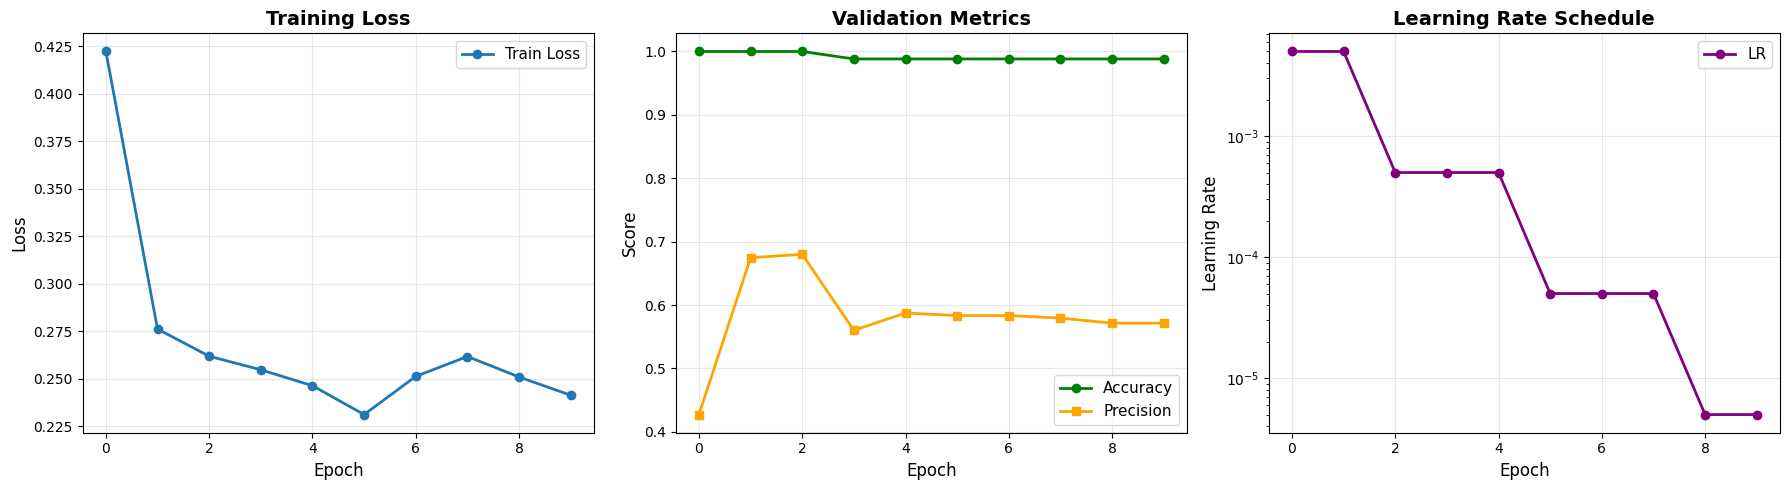

In [27]:
# 학습 결과 시각화
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loss
axes[0].plot(history['train_loss'], marker='o', linewidth=2, label='Train Loss')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Training Loss', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(alpha=0.3)

# Accuracy & Precision
axes[1].plot(history['val_accuracy'], marker='o', linewidth=2, label='Accuracy', color='green')
axes[1].plot(history['val_precision'], marker='s', linewidth=2, label='Precision', color='orange')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Score', fontsize=12)
axes[1].set_title('Validation Metrics', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(alpha=0.3)

# Learning Rate
axes[2].plot(history['learning_rate'], marker='o', linewidth=2, color='purple', label='LR')
axes[2].set_xlabel('Epoch', fontsize=12)
axes[2].set_ylabel('Learning Rate', fontsize=12)
axes[2].set_title('Learning Rate Schedule', fontsize=14, fontweight='bold')
axes[2].set_yscale('log')
axes[2].legend(fontsize=11)
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [28]:
# Best 모델 로드
print("\n=== Best Model 로드 ===")
checkpoint = torch.load('best_model.pth')
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
print(f"Best model (Epoch {checkpoint['epoch']}, Accuracy: {checkpoint['accuracy']:.4f}) 로드 완료!")


=== Best Model 로드 ===
Best model (Epoch 1, Accuracy: 1.0000) 로드 완료!


In [29]:
# 추론 및 시각화 함수
def predict_and_visualize(model, dataset, idx, device, conf_threshold=0.5):
    """단일 이미지 추론 및 시각화"""
    model.eval()

    # 이미지와 타겟 가져오기
    img, target = dataset[idx]

    # 추론
    with torch.no_grad():
        prediction = model([img.to(device)])[0]

    # CPU로 이동
    img_np = (img.permute(1, 2, 0).cpu().numpy() * 255).astype(np.uint8).copy()

    pred_boxes = prediction['boxes'].cpu().numpy()
    pred_scores = prediction['scores'].cpu().numpy()
    pred_labels = prediction['labels'].cpu().numpy()

    gt_boxes = target['boxes'].numpy()

    # Confidence threshold 적용
    mask = (pred_scores >= conf_threshold)
    pred_boxes = pred_boxes[mask]
    pred_scores = pred_scores[mask]

    # 시각화
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))

    # Ground Truth
    img_gt = img_np.copy()
    for box in gt_boxes:
        x1, y1, x2, y2 = box.astype(int)
        cv2.rectangle(img_gt, (x1, y1), (x2, y2), (0, 255, 0), 3)
        cv2.putText(img_gt, 'Person', (x1, y1-10),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

    axes[0].imshow(img_gt)
    axes[0].set_title(f'Ground Truth ({len(gt_boxes)} persons)', fontsize=14, fontweight='bold')
    axes[0].axis('off')

    # Prediction
    img_pred = img_np.copy()
    for box, score in zip(pred_boxes, pred_scores):
        x1, y1, x2, y2 = box.astype(int)
        cv2.rectangle(img_pred, (x1, y1), (x2, y2), (255, 0, 0), 3)
        text = f'Person: {score:.2f}'
        cv2.putText(img_pred, text, (x1, y1-10),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2)

    axes[1].imshow(img_pred)
    axes[1].set_title(f'Prediction ({len(pred_boxes)} persons, threshold: {conf_threshold})',
                     fontsize=14, fontweight='bold')
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

    print(f"Ground Truth: {len(gt_boxes)}명")
    print(f"Prediction: {len(pred_boxes)}명")
    if len(pred_boxes) > 0:
        print(f"Confidence 범위: {pred_scores.min():.3f} ~ {pred_scores.max():.3f}")

In [30]:
# 여러 샘플 테스트
print("\n=== 추론 결과 샘플 ===\n")

# Validation 세트에서 랜덤 샘플 선택
sample_indices = np.random.choice(len(val_dataset), size=min(5, len(val_dataset)), replace=False)

for i, idx in enumerate(sample_indices, 1): # enumerate(, 1) 1부터 시작해
    print(f"Sample {i}:")
    predict_and_visualize(model, val_dataset, idx, device, conf_threshold=0.5)
    print("-" * 60)

Output hidden; open in https://colab.research.google.com to view.


=== Confidence Threshold 영향 분석 ===

Threshold 0.3: 22개 검출
Threshold 0.5: 15개 검출
Threshold 0.7: 4개 검출
Threshold 0.9: 3개 검출


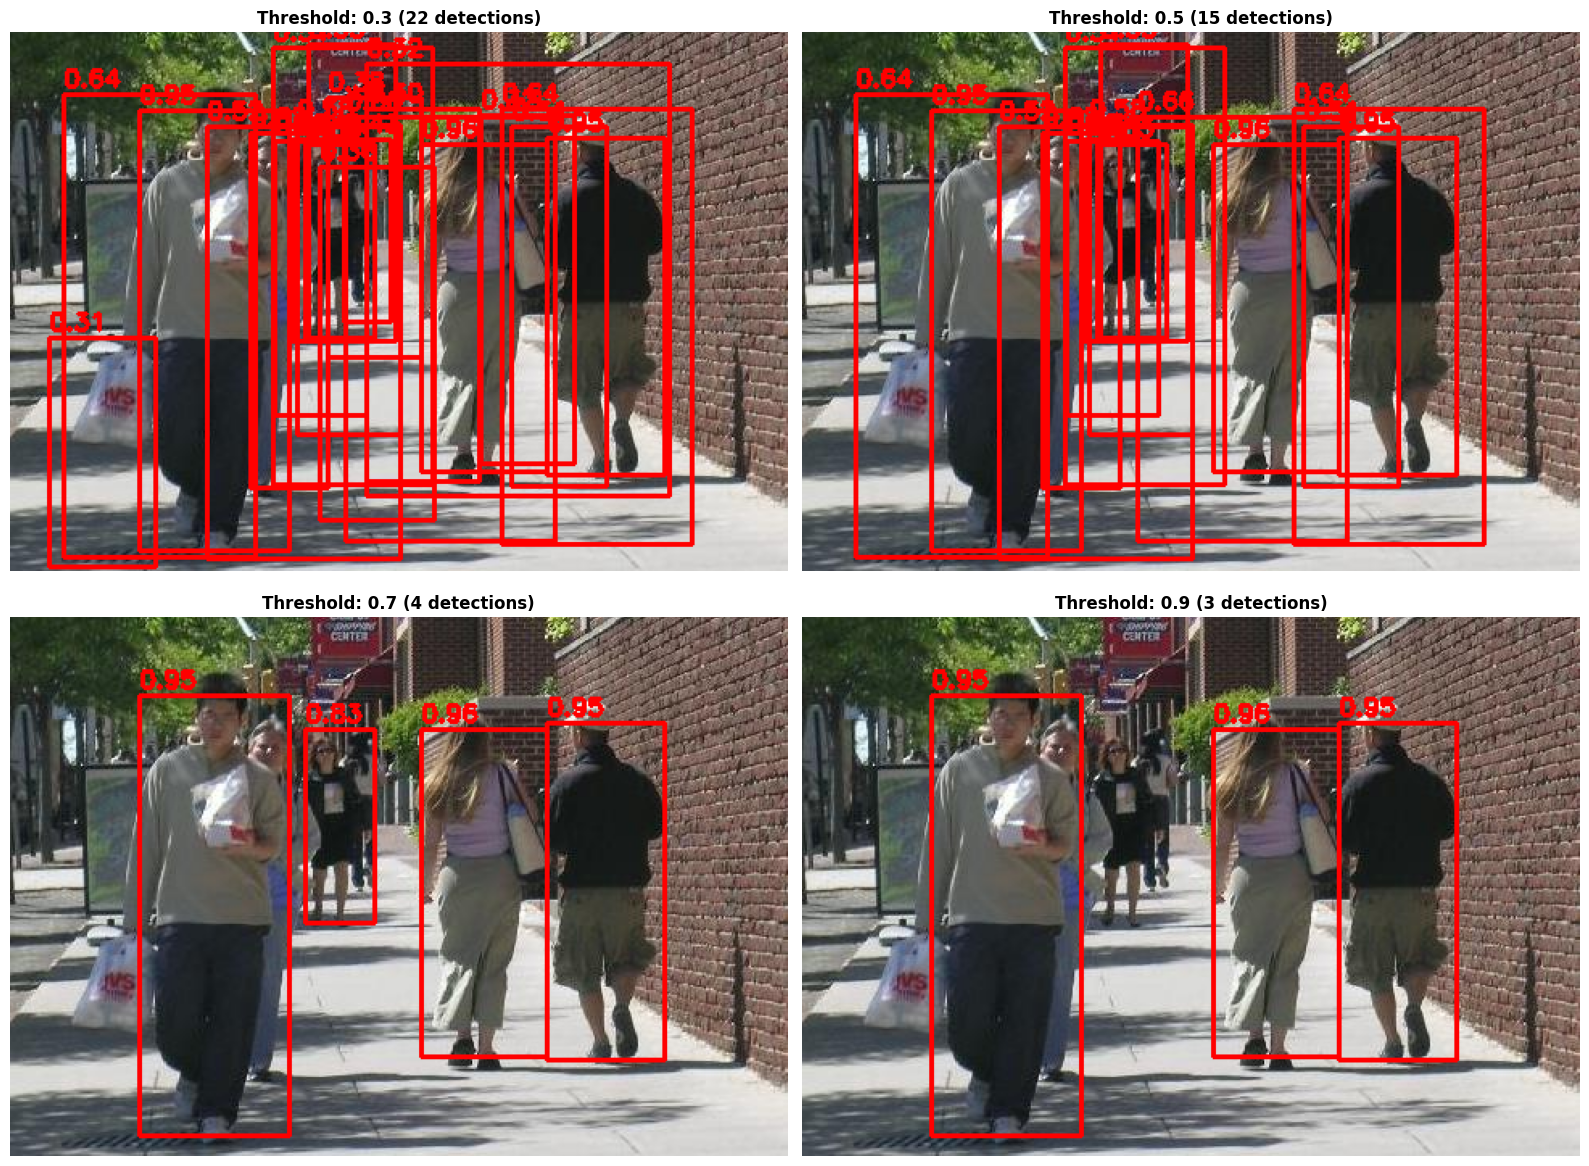

In [31]:
# Confidence Threshold 비교
print("\n=== Confidence Threshold 영향 분석 ===\n")

sample_idx = sample_indices[0]
thresholds = [0.3, 0.5, 0.7, 0.9]

img, target = val_dataset[sample_idx]
img_np = (img.permute(1, 2, 0).cpu().numpy() * 255).astype(np.uint8).copy()

with torch.no_grad():
    prediction = model([img.to(device)])[0]

pred_boxes = prediction['boxes'].cpu().numpy()
pred_scores = prediction['scores'].cpu().numpy()

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.ravel()

for idx, thresh in enumerate(thresholds):
    mask = pred_scores >= thresh
    boxes = pred_boxes[mask]
    scores = pred_scores[mask]

    img_temp = img_np.copy()
    for box, score in zip(boxes, scores):
        x1, y1, x2, y2 = box.astype(int)
        cv2.rectangle(img_temp, (x1, y1), (x2, y2), (255, 0, 0), 2)
        text = f'{score:.2f}'
        cv2.putText(img_temp, text, (x1, y1-5),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 2)

    axes[idx].imshow(img_temp)
    axes[idx].set_title(f'Threshold: {thresh} ({len(boxes)} detections)',
                       fontsize=12, fontweight='bold')
    axes[idx].axis('off')

    print(f"Threshold {thresh}: {len(boxes)}개 검출")

plt.tight_layout()
plt.show()

In [32]:
# 최종 성능 평가

final_metrics = evaluate(model, val_loader, device)

print(f"\nValidation Set 최종 결과:")
print(f"  Accuracy: {final_metrics['accuracy']:.4f}")
print(f"  Precision: {final_metrics['precision']:.4f}")
print(f"  Total Predictions: {final_metrics['total_predictions']}")
print(f"  Total Targets: {final_metrics['total_targets']}")

Evaluating: 100%|██████████| 9/9 [00:02<00:00,  3.70it/s]


Validation Set 최종 결과:
  Accuracy: 1.0000
  Precision: 0.4271
  Total Predictions: 199
  Total Targets: 85


In [33]:
# 최종 모델 저장
torch.save({
    'model_state_dict': model.state_dict(),
    'num_classes': 2,
    'history': history,
    'final_metrics': final_metrics
}, 'final_model.pth')

In [34]:
# 요약 정리
print("실습 요약:")
print(f"  • 데이터셋: Penn-Fudan Pedestrian Detection")
print(f"  • Train 샘플: {len(train_dataset)}개")
print(f"  • Val 샘플: {len(val_dataset)}개")
print(f"  • Epochs: {num_epochs}")
print(f"  • Best Validation Accuracy: {best_accuracy:.4f}")
print(f"  • 총 학습 시간: {total_time/60:.1f}분")


실습 요약:
  • 데이터셋: Penn-Fudan Pedestrian Detection
  • Train 샘플: 136개
  • Val 샘플: 34개
  • Epochs: 10
  • Best Validation Accuracy: 1.0000
  • 총 학습 시간: 3.6분


브로드 캐스팅 실습

In [9]:
import numpy as np

mask =\
np.array([
    [0,1,1,2],
    [0,1,2,2],
    [0,0,2,1]
])

mask.shape

(3, 4)

In [10]:
# 찾고 싶은 객체 id >> [1,2] 사람
obj_ids = np.array([1,2])
obj_ids.shape

(2,)

In [11]:
# 차원추가
obj_ids_exp = obj_ids[:,None,None]
print(obj_ids_exp)
print()
print(obj_ids_exp.shape)

[[[1]]

 [[2]]]

(2, 1, 1)


In [13]:
# 브로드 캐스팅
masks = (obj_ids_exp == mask)
print(masks)
print(masks.shape)

[[[False  True  True False]
  [False  True False False]
  [False False False  True]]

 [[False False False  True]
  [False False  True  True]
  [False False  True False]]]
(2, 3, 4)


In [17]:
# randperm
# 무작위 순열 생성 (0-4 랜덤순서로 배열)
torch.randperm(5)

tensor([1, 4, 2, 3, 0])